In [ ]:
pip install deap numpy matplotlib

**1. REQUIRED LIBRARIES**

In [ ]:
import numpy as np  # For numerical operations and arrays
import matplotlib.pyplot as plt  # For plotting and visualizations
from sklearn.datasets import load_breast_cancer  # To load the breast cancer dataset
from sklearn.model_selection import train_test_split  # To split data into training and testing sets
from sklearn.metrics import accuracy_score  # To calculate prediction accuracy
from sklearn.tree import DecisionTreeClassifier  # Decision Tree classifier for evaluation
from deap import base, creator, tools, algorithms  # Core components of DEAP for evolutionary algorithms
import random  # For random number generation and sampling
import copy  # For copying individuals or populations
from scipy.stats import mannwhitneyu  # For statistical comparison using the Mann-Whitney U test


**2. GENETIC CONFIGURATION**

In [ ]:
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # Defines a fitness class where higher values are better (maximization)

if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)  # Defines an individual as a list with an associated fitness value

toolbox = base.Toolbox()  # Toolbox to register evolutionary operators

toolbox.register("attr_bool", random.randint, 0, 1)  # Registers a function to generate random binary values (0 or 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, 30)  # Creates an individual of length 30 using attr_bool
toolbox.register("population", tools.initRepeat, list, toolbox.individual)  # Creates a population as a list of individuals

toolbox.register("mate", tools.cxTwoPoint)  # Registers two-point crossover operator
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)  # Registers bit-flip mutation with 10% probability per bit
toolbox.register("select", tools.selTournament, tournsize=3)  # Registers tournament selection with size 3



**3. DATA LOADING**

In [ ]:
data = load_breast_cancer()  # Load the Breast Cancer dataset from scikit-learn
X, y = data.data, data.target  # Separate features (X) and labels (y)

def make_deceptive_data(X, y, noise_std=0.1, label_flip_ratio=0.2):
    X_noisy = X + np.random.normal(0, noise_std, X.shape)  # Add Gaussian noise to the features
    y_noisy = y.copy()  # Copy labels to avoid modifying the original array
    flip_indices = np.random.choice(len(y), int(len(y) * label_flip_ratio), replace=False)  # Choose indices to flip
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]  # Flip the selected labels (0↔1)
    return X_noisy, y_noisy  # Return the noisy features and modified labels


**4. EVALUATION FUNCTIONS**

In [ ]:
def eval_features(individual, X, y):
    # Return 0 accuracy if no features are selected
    if sum(individual) == 0:
        return 0.0,
    # Convert binary individual to boolean mask for feature selection
    selected = np.array(individual, dtype=bool)
    X_sel = X[:, selected]  # Select the corresponding features
    # Split the selected data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=42)
    clf = DecisionTreeClassifier()  # Create a decision tree classifier
    clf.fit(X_train, y_train)  # Train the model
    acc = accuracy_score(y_test, clf.predict(X_test))  # Calculate accuracy on the test set
    return acc,  # Return accuracy as a tuple

def calculate_diversity(population):
    # Convert the population (list of individuals) to a NumPy array
    pop_array = np.array([ind[:] for ind in population])
    # Compute average standard deviation across all gene positions
    return np.mean(np.std(pop_array, axis=0))



**5. GENETIC ALGORITHM RUNNER**

In [ ]:
def run_ea(X_data, y_data, transferred_population=None, ngen=20, pop_size=30, cxpb=0.5, mutpb=0.2):
    toolbox.register("evaluate", lambda ind: eval_features(ind, X_data, y_data))  # Register fitness eval with current data

    pop = toolbox.population(n=pop_size)  # Initialize population
    hof = tools.HallOfFame(1)  # Keep best individual

    if transferred_population:
        for i in range(min(len(transferred_population), len(pop))):
            pop[i] = creator.Individual(transferred_population[i])  # Insert transferred individuals

    acc_list, diversity_list = [], []  # Track accuracy and diversity per generation

    for gen in range(ngen):
        offspring = algorithms.varAnd(pop, toolbox, cxpb=cxpb, mutpb=mutpb)  # Apply crossover & mutation
        fits = list(map(toolbox.evaluate, offspring))  # Evaluate offspring fitness
        for ind, fit in zip(offspring, fits):
            ind.fitness.values = fit  # Assign fitness
        pop = toolbox.select(offspring, k=len(pop))  # Select next gen
        hof.update(pop)  # Update Hall of Fame
        acc_list.append(max(ind.fitness.values[0] for ind in pop))  # Record best accuracy
        diversity_list.append(calculate_diversity(pop))  # Record population diversity

    return acc_list, diversity_list, hof[0], pop  # Return stats and best individual


**6. TRANSFER STRATEGIES**

In [ ]:
def transfer_strategies(source_pop, method="30-Best"):
    if method == "30-Best":
        best = tools.selBest(source_pop, 1)[0]  # Select the single best individual
        return [copy.deepcopy(best)] * 9 + [toolbox.individual() for _ in range(21)]  # 9 copies of best + 21 new random individuals
    elif method == "100-Best":
        best = tools.selBest(source_pop, 1)[0]  # Select the single best individual
        return [copy.deepcopy(best) for _ in range(30)]  # 30 copies of best individual
    elif method == "30-Top":
        top30 = tools.selBest(source_pop, 9)  # Select top 9 individuals
        return [copy.deepcopy(ind) for ind in top30] + [toolbox.individual() for _ in range(21)]  # 9 best + 21 random
    elif method == "100-Top":
        return [copy.deepcopy(ind) for ind in source_pop]  # Copy entire source population (all 30)
    elif method == "ED":
        pop_array = np.array([ind[:] for ind in source_pop])  # Convert population to numpy array
        probs = np.mean(pop_array, axis=0)  # Calculate mean gene activation probability
        # Create new individuals probabilistically based on mean gene activation
        return [creator.Individual([1 if random.random() < p else 0 for p in probs]) for _ in range(30)]
    elif method == "Random":
        return toolbox.population(n=30)  # Generate 30 new random individuals
    else:
        raise ValueError("Unknown strategy:", method)  # Error for unknown method


**7. PLOTS**

In [ ]:
def plot_all_levels(results, methods, source_accs, source_divs, base_method="Random"):
    # Create a 3x3 grid of subplots for accuracy, diversity, and difference per level
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    colors = plt.colormaps['tab10'].resampled(len(methods))  # Get distinct colors for each method
    method_colors = {m: colors(i) for i, m in enumerate(methods)}  # Map methods to colors

    for lvl in range(1, 4):
        ax_acc = axes[lvl-1, 0]   # Accuracy subplot for this level
        ax_div = axes[lvl-1, 1]   # Diversity subplot for this level
        ax_diff = axes[lvl-1, 2]  # Difference subplot for this level

        src_acc = source_accs[f"level{lvl}"]
        ax_acc.plot(src_acc, 'r--', label="Source Accuracy", linewidth=2)  # Plot source accuracy baseline

        src_div = source_divs[f"level{lvl}"]
        ax_div.plot(src_div, 'r--', label="Source Diversity", linewidth=2)  # Plot source diversity baseline

        for method in methods:
            key = f"level{lvl}_{method}"
            ax_acc.plot(results[key]["acc"], label=method, color=method_colors[method])  # Plot accuracy per method
        ax_acc.set_title(f"Level {lvl} - Accuracy")
        ax_acc.set_xlabel("Generation")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.grid(True)

        for method in methods:
            key = f"level{lvl}_{method}"
            ax_div.plot(results[key]["div"], label=method, color=method_colors[method])  # Plot diversity per method
        ax_div.set_title(f"Level {lvl} - Diversity")
        ax_div.set_xlabel("Generation")
        ax_div.set_ylabel("Mean Std Deviation")
        ax_div.grid(True)

        for method in methods:
            if method == base_method:
                continue
            key_method = f"level{lvl}_{method}"
            key_base = f"level{lvl}_{base_method}"
            delta = np.array(results[key_method]["acc"]) - np.array(results[key_base]["acc"])  # Difference from baseline
            ax_diff.plot(delta, label=method, color=method_colors[method])
        ax_diff.axhline(0, linestyle="--", color="gray")  # Reference line at zero
        ax_diff.set_title(f"Level {lvl} - Transfer Effect Difference")
        ax_diff.set_xlabel("Generation")
        ax_diff.set_ylabel("Δ Accuracy")
        ax_diff.grid(True)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(methods)+1, bbox_to_anchor=(0.5, 1.02))  # Global legend
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def plot_performance_comparison(results, methods):
    # Plot average accuracy across deceptive levels for each method
    levels = ["level1", "level2", "level3"]
    colors = {
        "30-Best": 'blue',
        "100-Best": 'orange',
        "30-Top": 'purple',
        "100-Top": 'brown',
        "ED": 'green',
        "Random": 'red'
    }

    plt.figure(figsize=(8, 5))

    for method in methods:
        avg_accs = []
        for lvl in levels:
            key = f"{lvl}_{method}"
            acc = results[key]["acc"]
            avg_accs.append(np.mean(acc))  # Compute mean accuracy per level
        plt.plot(["Level 1", "Level 2", "Level 3"], avg_accs, label=method, color=colors[method], marker='o')

    plt.xlabel("Deceptive Levels")
    plt.ylabel("Average Accuracy")
    plt.title("Performance Comparison of Different Transfer Strategies")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def statistical_tests(results, methods, base_method="Random", alpha=0.05):
    # Perform Mann-Whitney U statistical test comparing each method against baseline
    print("\n=== STATISTICAL COMPARISONS (Mann-Whitney U Test) ===")
    for lvl in range(1, 4):
        print(f"\n--- Level {lvl} ---")
        key_base = f"level{lvl}_{base_method}"
        base_acc = results[key_base]["acc"]
        for method in methods:
            if method == base_method:
                continue
            key_method = f"level{lvl}_{method}"
            test_acc = results[key_method]["acc"]
            stat, p = mannwhitneyu(test_acc, base_acc, alternative='two-sided')
            signif = "(Significant)" if p < alpha else "(Not Significant)"
            print(f"{method} vs {base_method} → p-value: {p:.4f} {signif}")


**8. EXPERIMENT STRUCTURE**

In [ ]:
deceptive_levels = [
    {"label_flip_ratio": 0.1, "noise_std": 0.1},  # Mild noise and label flipping
    {"label_flip_ratio": 0.3, "noise_std": 0.3},  # Moderate noise and label flipping
    {"label_flip_ratio": 0.5, "noise_std": 0.5}   # Severe noise and label flipping
]

methods = ["30-Best", "100-Best", "30-Top", "100-Top", "ED", "Random"]  # Transfer strategies to test
results = {}  # Dictionary to store results of each method and level
source_accs = {}  # Source population accuracy history per level
source_divs = {}  # Source population diversity history per level

for i, level in enumerate(deceptive_levels, start=1):
    print(f"\n=== Deceptive Level {i} ===")
    print(f"Noise Std Dev: {level['noise_std']}, Label Flip Ratio: {level['label_flip_ratio']}")

    X_src, y_src = make_deceptive_data(X, y, **level)  # Create noisy/deceptive source data
    X_tgt, y_tgt = X_src, y_src  # Target data is same as source in this setup

    acc_src, div_src, hof_src, pop_src = run_ea(X_src, y_src)  # Run EA on source data
    source_accs[f"level{i}"] = acc_src  # Store source accuracy over generations
    source_divs[f"level{i}"] = div_src  # Store source diversity over generations

    for method in methods:
        transferred_pop = transfer_strategies(pop_src, method=method)  # Generate transferred population based on strategy
        acc_tgt, div_tgt, hof_tgt, pop_tgt = run_ea(X_tgt, y_tgt, transferred_population=transferred_pop)  # Run EA on target with transfer
        results[f"level{i}_{method}"] = {"acc": acc_tgt, "div": div_tgt}  # Store results per method and level
        print(f"{method} transfer completed.")  # Log completion



=== Deceptive Level 1 ===
Noise Std Dev: 0.1, Label Flip Ratio: 0.1
30-Best transfer completed.
100-Best transfer completed.
30-Top transfer completed.
100-Top transfer completed.
ED transfer completed.
Random transfer completed.

=== Deceptive Level 2 ===
Noise Std Dev: 0.3, Label Flip Ratio: 0.3
30-Best transfer completed.
100-Best transfer completed.
30-Top transfer completed.
100-Top transfer completed.
ED transfer completed.
Random transfer completed.

=== Deceptive Level 3 ===
Noise Std Dev: 0.5, Label Flip Ratio: 0.5
30-Best transfer completed.
100-Best transfer completed.
30-Top transfer completed.
100-Top transfer completed.
ED transfer completed.
Random transfer completed.


**9. RESULT PLOTS & ANALYSIS**

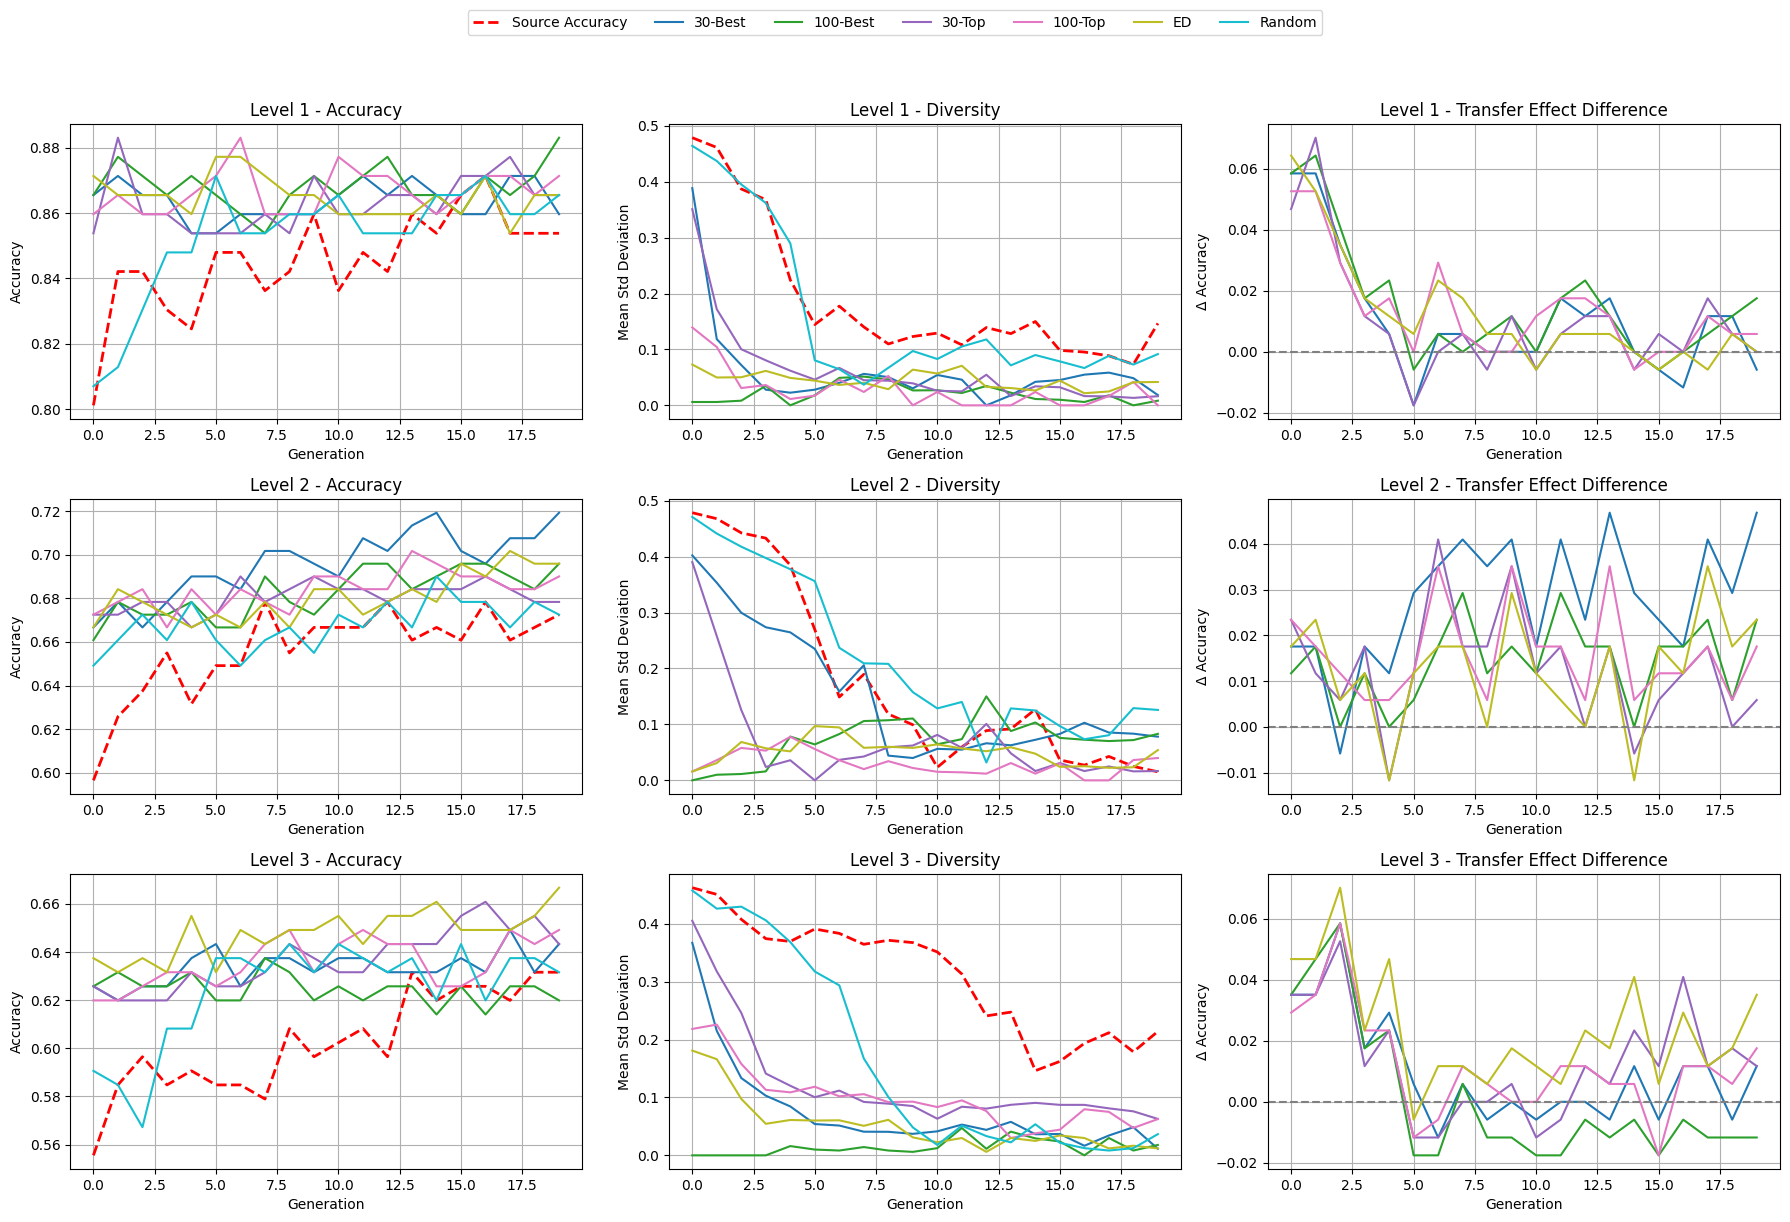

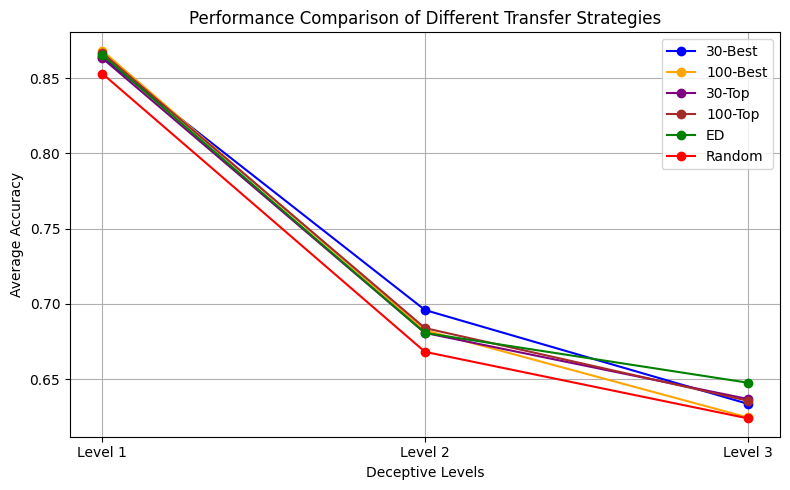


=== STATISTICAL COMPARISONS (Mann-Whitney U Test) ===

--- Level 1 ---
30-Best vs Random → p-value: 0.0132 (Significant)
100-Best vs Random → p-value: 0.0002 (Significant)
30-Top vs Random → p-value: 0.0532 (Not Significant)
100-Top vs Random → p-value: 0.0012 (Significant)
ED vs Random → p-value: 0.0039 (Significant)

--- Level 2 ---
30-Best vs Random → p-value: 0.0000 (Significant)
100-Best vs Random → p-value: 0.0006 (Significant)
30-Top vs Random → p-value: 0.0002 (Significant)
100-Top vs Random → p-value: 0.0000 (Significant)
ED vs Random → p-value: 0.0017 (Significant)

--- Level 3 ---
30-Best vs Random → p-value: 0.4300 (Not Significant)
100-Best vs Random → p-value: 0.1279 (Not Significant)
30-Top vs Random → p-value: 0.0950 (Not Significant)
100-Top vs Random → p-value: 0.1183 (Not Significant)
ED vs Random → p-value: 0.0000 (Significant)


In [ ]:
plot_all_levels(results, methods, source_accs, source_divs, base_method="Random")
# Plot accuracy, diversity, and difference graphs for all levels and methods

plot_performance_comparison(results, methods)
# Plot average accuracy comparison across deceptive levels for all methods

statistical_tests(results, methods)
# Perform statistical Mann-Whitney U tests comparing each method against baseline (Random)
